# Synthea FHIR Output Analysis

Analyse the patient bundles generated by Synthea to inform cleanup decisions.

## Run Synthea

In [15]:
from pathlib import Path
import shutil
import subprocess


SYNTHEA_DIR: Path = Path("~/Developer/misc/synthea")
AGE_RANGE: str = "55-85"
EXPORTER_BASE_DIRECTORY: Path = Path("~/Developer/misc/synthea/output/raw")
FHIR_DIRECTORY: Path = EXPORTER_BASE_DIRECTORY.expanduser() / "fhir"
EXPORTER_YEARS_OF_HISTORY: int = 3
GENERATE_ONLY_ALIVE_PATIENTS = True
LOCAL_MODULES_DIR_PATH: Path = Path("~/Developer/misc/iris-fhir-converter-demo/src/DSE/synthea")
POPULATION_SIZE: int = 10

# Keep module: exports only patients matching this criteria; None disables filtering.
KEEP_MODULE_PATH: Path | None = Path("~/Developer/misc/iris-fhir-converter-demo/skills/synthea-module-author/keep_modules/keep_has_all_hapi_inputs.json")


def clear_exporter_base_directory() -> None:
    """Remove any existing output so each run starts from an empty directory."""
    directory = EXPORTER_BASE_DIRECTORY.expanduser()
    if directory.exists():
        shutil.rmtree(directory)


def parse_age_range(age_range: str) -> tuple[int, int]:
    """Split "min-max" into (min_age, max_age)."""
    min_age_str, max_age_str = age_range.split("-")
    return int(min_age_str), int(max_age_str)


def resolve_years_of_history() -> int:
    """Keep enough history that keep-module criteria survive export trimming.

    All HAPI augmentation modules gate on Age >= 55, so a qualifying event can
    be at most (max_age - min_age) years old relative to "now". A keep module
    checks the full internal record, but export trims separately by
    years_of_history — using 0 (entire life) avoids that bug but produces huge,
    slow-to-import bundles, so size the window instead of disabling trimming.
    """
    if KEEP_MODULE_PATH is None:
        return EXPORTER_YEARS_OF_HISTORY

    min_age, max_age = parse_age_range(AGE_RANGE)
    return max(EXPORTER_YEARS_OF_HISTORY, max_age - min_age + 1)


def run_synthea() -> str:
    """Run Synthea with the specified parameters and return the output as a string."""

    command = [
        "./run_synthea",
        "-p", str(POPULATION_SIZE),
        "-s", str(42), # seed
        "-a", AGE_RANGE,
        "-d", str(LOCAL_MODULES_DIR_PATH.expanduser()),
    ]

    if KEEP_MODULE_PATH is not None:
        command += ["-k", str(KEEP_MODULE_PATH.expanduser())]

    # Override values for Synthea properties
    command.append(f"--exporter.baseDirectory={EXPORTER_BASE_DIRECTORY.expanduser()!s}")
    command.append(f"--exporter.years_of_history={resolve_years_of_history()}")
    command.append(f"--generate.only_alive_patients={'true' if GENERATE_ONLY_ALIVE_PATIENTS else 'false'}")

    print("Running:", " ".join(command))

    result = subprocess.run(
        command,
        cwd=SYNTHEA_DIR.expanduser(),
        text=True,
        capture_output=True,
        check=False,
    )

    if result.returncode != 0:
        raise RuntimeError(
            f"Synthea failed with exit code {result.returncode}\n"
            f"{result.stderr}"
        )

    return result.stdout


def rename_fhir_metadata_files() -> None:
    """Prefix Synthea metadata files so dependency-aware importers read them first."""

    metadata_prefixes = {
        "hospitalInformation": "00_hospitalInformation",
        "practitionerInformation": "01_practitionerInformation",
    }

    for source_prefix, target_prefix in metadata_prefixes.items():
        for source in FHIR_DIRECTORY.glob(f"{source_prefix}*.json"):
            target = source.with_name(target_prefix + source.name[len(source_prefix):])
            if target.exists():
                raise FileExistsError(f"Refusing to overwrite existing file: {target}")
            source.rename(target)


clear_exporter_base_directory()
output = run_synthea()
rename_fhir_metadata_files()
# print(output)

Running: ./run_synthea -p 10 -s 42 -a 55-85 -d /Users/8826/Developer/misc/iris-fhir-converter-demo/src/DSE/synthea -k /Users/8826/Developer/misc/iris-fhir-converter-demo/skills/synthea-module-author/keep_modules/keep_has_all_hapi_inputs.json --exporter.baseDirectory=/Users/8826/Developer/misc/synthea/output/raw --exporter.years_of_history=31 --generate.only_alive_patients=true


In [16]:
import json
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from ipywidgets import HBox, VBox, interactive_output
from tqdm.notebook import tqdm


files: list[Path] = sorted(
    (
        file
        for file in FHIR_DIRECTORY.glob("*.json")
        if not file.name.startswith(("00_hospitalInformation", "01_practitionerInformation"))
    ),
    key=lambda file: file.name,
)
sizes_mb: list[float] = [f.stat().st_size / (1024 * 1024) for f in files]

print(f"Total files : {len(files)}")
print(f"Min size    : {min(sizes_mb):.2f} MB" if sizes_mb else "No files found")
print(f"Max size    : {max(sizes_mb):.2f} MB")
print(f"Median size : {np.median(sizes_mb):.2f} MB")
print(f"Mean size   : {np.mean(sizes_mb):.2f} MB")

bins_slider = widgets.IntSlider(value=50, min=5, max=200, step=5, description="Bins")
threshold_slider = widgets.FloatSlider(
    value=round(np.median(sizes_mb), 2),
    min=round(min(sizes_mb), 2),
    max=round(max(sizes_mb), 2),
    step=0.01,
    description="Threshold (MB)",
    style={"description_width": "initial"},
    readout_format=".2f",
)

def plot_histogram(bins: int, threshold: float) -> None:
    below = sum(1 for s in sizes_mb if s <= threshold)
    above = len(sizes_mb) - below

    fig, ax = plt.subplots(figsize=(30, 4))
    ax.hist(sizes_mb, bins=bins, edgecolor="white", linewidth=0.4)
    ax.axvline(threshold, color="crimson", linewidth=1.5, linestyle="--", label=f"Threshold: {threshold:.2f} MB")
    ax.set_xlabel("File size (MB)")
    ax.set_ylabel("Number of files")
    ax.set_title(
        f"Synthea patient bundle size distribution  |  "
        f"≤ {threshold:.2f} MB: {below} files   >  {threshold:.2f} MB: {above} files"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close(fig)  # avoid a duplicate static plot from the inline backend

out = interactive_output(plot_histogram, {"bins": bins_slider, "threshold": threshold_slider})
display(VBox([HBox([bins_slider, threshold_slider]), out]))


Total files : 10
Min size    : 3.92 MB
Max size    : 63.98 MB
Median size : 9.01 MB
Mean size   : 14.32 MB


In [17]:
import ipywidgets as widgets
import numpy as np
from IPython.display import display
from ipywidgets import HBox, VBox, interactive_output

cumulative_mb: list[float] = list(np.cumsum(sizes_mb))

index_slider = widgets.IntSlider(
    value=len(files),
    min=1,
    max=len(files),
    step=1,
    description="Index (n)",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="600px"),
)

size_threshold_slider = widgets.FloatSlider(
    value=round(np.median(sizes_mb), 2),
    min=round(min(sizes_mb), 2),
    max=round(max(sizes_mb), 2),
    step=0.01,
    description="Max file size (MB)",
    style={"description_width": "initial"},
    readout_format=".2f",
    layout=widgets.Layout(width="600px"),
)

index_label = widgets.HTML()
filter_label = widgets.HTML()

def update_index(n: int, size_threshold: float) -> None:
    total = cumulative_mb[n - 1]
    index_label.value = (
        f"<b>First {n} files</b> (alphabetical) — "
        f"cumulated size: <b>{total:.2f} MB</b> &nbsp;|&nbsp; "
        f"remaining {len(files) - n} files: <b>{cumulative_mb[-1] - total:.2f} MB</b>"
    )
    small = [(f, s) for f, s in zip(files, sizes_mb) if s <= size_threshold]
    small_total = sum(s for _, s in small)
    filter_label.value = (
        f"Files ≤ <b>{size_threshold:.2f} MB</b>: <b>{len(small)}</b> files &nbsp;|&nbsp; "
        f"cumulated size: <b>{small_total:.2f} MB</b>"
    )

out = interactive_output(update_index, {"n": index_slider, "size_threshold": size_threshold_slider})
display(VBox([HBox([index_slider, size_threshold_slider]), index_label, filter_label, out]))

In [18]:
from pathlib import Path
import shutil


SIZE_LIMIT_MB: float = 25.0

too_heavy_directory: Path = FHIR_DIRECTORY / "too_heavy"
too_heavy_directory.mkdir(parents=True, exist_ok=True)

moved = 0
for file, size_mb in zip(files, sizes_mb):
    if size_mb > SIZE_LIMIT_MB:
        shutil.move(str(file), str(too_heavy_directory / file.name))
        moved += 1

print(f"Moved {moved} file(s) over {SIZE_LIMIT_MB:.0f} MB to {too_heavy_directory}")
print(f"Remaining usable files: {len(files) - moved}")

Moved 1 file(s) over 25 MB to /Users/8826/Developer/misc/synthea/output/raw/fhir/too_heavy
Remaining usable files: 9


## HAPI Input Coverage

For each remaining patient record, determine which of the 21 HAPI risk-model inputs (excluding `age`, which is always present) have supporting FHIR data, using a real FHIR client (`fhir.resources`) rather than raw JSON parsing.

In [19]:
from fhir.resources.R4B.bundle import Bundle

# Definitions grounded in src/DSE/synthea/*.json and src/DSE/python/DSE/models.py.
# "age" is excluded — it is always present via Patient.birthDate, not a generated input.
HAPI_INPUT_DEFINITIONS: dict[str, dict] = {
    "albumin": {"resource": "Observation", "codes": {"1751-7"}},
    "bun": {"resource": "Observation", "codes": {"3094-0"}},
    "chloride": {"resource": "Observation", "codes": {"2075-0"}},
    "rdw_cv": {"resource": "Observation", "codes": {"788-0"}},
    "braden_mobility": {"resource": "Observation", "codes": {"38224-2"}},
    "braden_moisture": {"resource": "Observation", "codes": {"38229-1"}},
    "braden_activity": {"resource": "Observation", "codes": {"38223-4"}},
    "braden_friction": {"resource": "Observation", "codes": {"38226-7"}},
    "braden_sensory": {"resource": "Observation", "codes": {"38222-6"}},
    "gait_transfer": {"resource": "Observation", "codes": {"93015-6"}},
    "is_on_gim_service": {"resource": "Observation", "codes": {"gim-service"}},
    "has_edema": {"resource": "Condition", "codes": {"79654002"}},
    "has_spinal_cord_injury": {"resource": "Condition", "codes": {"90584004", "1734006"}},
    "is_icu_admitted": {"resource": "Condition", "codes": {"309904001"}},
    "has_tracheostomy": {"resource": "Procedure", "codes": {"55622001"}},
    "has_central_line": {"resource": "Procedure", "codes": {"392230005"}},
    "has_chest_tube": {"resource": "Procedure", "codes": {"177788009"}},
    "has_ostomy": {"resource": "Procedure", "codes": {"4044002"}},
    "is_on_ecmo": {"resource": "Procedure", "codes": {"233573008"}},
    # MedicationRequest.medicationReference points at a separate Medication resource in Synthea's
    # export, rather than an inline medicationCodeableConcept, so these are resolved via reference.
    "is_on_vasopressin": {"resource": "MedicationRequest", "codes": {"11149"}},
    "is_on_cardio_sympathomimetic": {"resource": "MedicationRequest", "codes": {"3628", "7512", "3992", "8163"}},
}
assert len(HAPI_INPUT_DEFINITIONS) == 21


def extract_codes(resource) -> set[str]:
    """Return the coding.code values on a resource's primary CodeableConcept."""
    code_field = getattr(resource, "code", None)
    if code_field is None or not code_field.coding:
        return set()
    return {coding.code for coding in code_field.coding if coding.code}


def hapi_inputs_present(bundle: Bundle) -> set[str]:
    """Return the HAPI_INPUT_DEFINITIONS keys with matching data in this bundle."""
    medication_codes_by_url: dict[str, set[str]] = {}
    resources_by_type: dict[str, list] = {}

    for entry in bundle.entry or []:
        resource = entry.resource
        resource_type = type(resource).__name__
        resources_by_type.setdefault(resource_type, []).append(resource)
        if resource_type == "Medication":
            medication_codes_by_url[entry.fullUrl] = extract_codes(resource)

    present: set[str] = set()
    for field_name, definition in HAPI_INPUT_DEFINITIONS.items():
        target_codes = definition["codes"]
        for resource in resources_by_type.get(definition["resource"], []):
            if definition["resource"] == "MedicationRequest":
                reference = resource.medicationReference.reference if resource.medicationReference else None
                candidate_codes = medication_codes_by_url.get(reference, set())
            else:
                candidate_codes = extract_codes(resource)
            if candidate_codes & target_codes:
                present.add(field_name)
                break

    return present


# Re-glob rather than reuse `files` from earlier, since the cleanup cell may have moved
# oversized files out of FHIR_DIRECTORY since that list was computed.
usable_files: list[Path] = sorted(
    (
        file
        for file in FHIR_DIRECTORY.glob("*.json")
        if not file.name.startswith(("00_hospitalInformation", "01_practitionerInformation"))
    ),
    key=lambda file: file.name,
)

hapi_input_counts: list[int] = []
hapi_presence_by_file: dict[str, set[str]] = {}
failed_files: list[str] = []

for file in tqdm(usable_files, desc="Analysing HAPI inputs"):
    try:
        bundle = Bundle.model_validate_json(file.read_bytes())
    except Exception as error:
        failed_files.append(f"{file.name}: {error}")
        continue
    present = hapi_inputs_present(bundle)
    hapi_presence_by_file[file.name] = present
    hapi_input_counts.append(len(present))

print(f"Analysed {len(hapi_input_counts)} / {len(usable_files)} patient records")
print(f"HAPI inputs tracked: {len(HAPI_INPUT_DEFINITIONS)}")
if failed_files:
    print(f"Failed to parse {len(failed_files)} file(s):")
    for failure in failed_files:
        print(" -", failure)

Analysing HAPI inputs:   0%|          | 0/9 [00:00<?, ?it/s]

Analysed 9 / 9 patient records
HAPI inputs tracked: 21


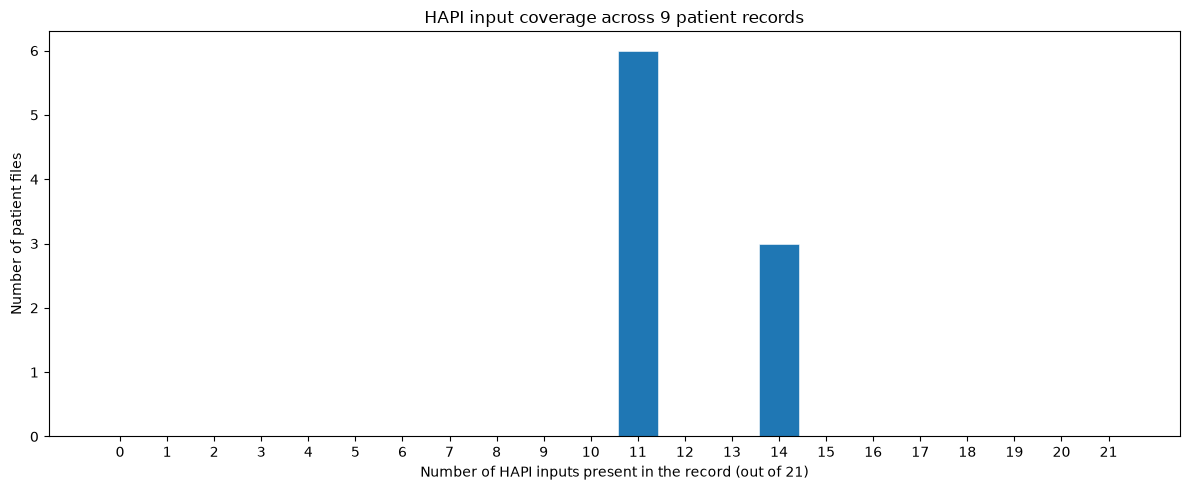

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
bins = range(0, len(HAPI_INPUT_DEFINITIONS) + 2)
ax.hist(hapi_input_counts, bins=bins, align="left", edgecolor="white", linewidth=0.4, rwidth=0.85)
ax.set_xlabel("Number of HAPI inputs present in the record (out of 21)")
ax.set_ylabel("Number of patient files")
ax.set_title(f"HAPI input coverage across {len(hapi_input_counts)} patient records")
ax.set_xticks(range(0, len(HAPI_INPUT_DEFINITIONS) + 1))
plt.tight_layout()
plt.show()
plt.close(fig)

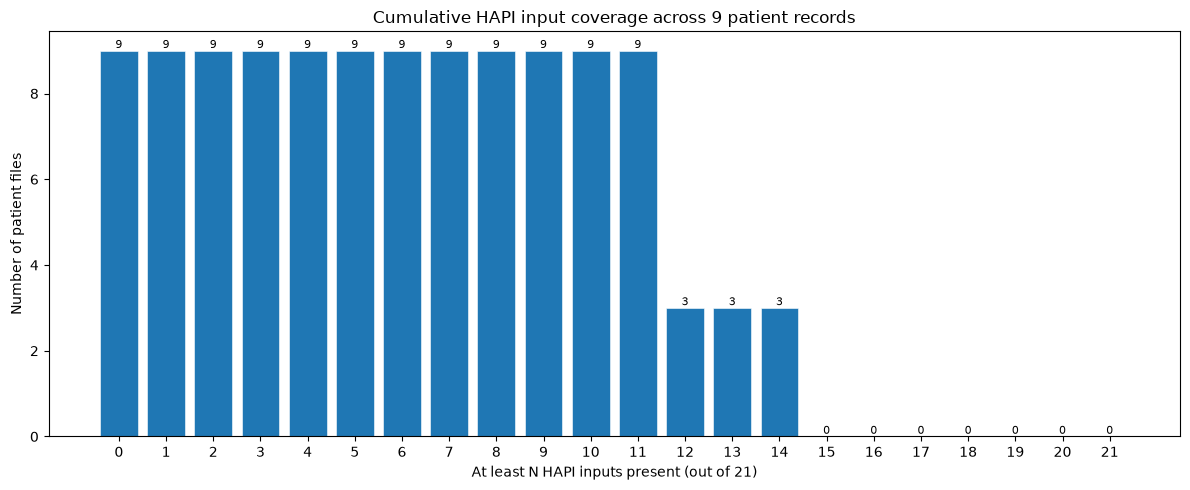

In [21]:
import matplotlib.pyplot as plt

max_inputs = len(HAPI_INPUT_DEFINITIONS)
thresholds = list(range(0, max_inputs + 1))
counts_at_least = [
    sum(1 for count in hapi_input_counts if count >= threshold)
    for threshold in thresholds
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(thresholds, counts_at_least, edgecolor="white", linewidth=0.4)
ax.set_xlabel("At least N HAPI inputs present (out of 21)")
ax.set_ylabel("Number of patient files")
ax.set_title(f"Cumulative HAPI input coverage across {len(hapi_input_counts)} patient records")
ax.set_xticks(thresholds)
for threshold, count in zip(thresholds, counts_at_least):
    ax.text(threshold, count, str(count), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()
plt.close(fig)